<a href="https://colab.research.google.com/github/rai8896/Deep_Learning_Lab/blob/main/Experiment10_ViT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 10 - Vision Transformer vs ResNet-18
**Dataset:** CIFAR-10 | **Models:** ViT, ResNet-18

In [ ]:
!pip install wandb huggingface_hub -q

In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: manishrai_25afi23 (manishrai_25afi23-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "mraidtu/exp10-vit-resnet"

WANDB_PROJECT = "exp10-vit-resnet"
EPOCHS        = 4
BATCH_SIZE    = 128
NUM_CLASSES   = 10
PATCH_SIZE    = 4
IMG_SIZE      = 32
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["ce", "label_smooth", "focal"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vit", "resnet18"]
AUG_MODES  = ["no_aug", "aug"]

class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print(DEVICE)

cuda


### Dataset - Original and Augmented

100%|██████████| 170M/170M [00:14<00:00, 11.9MB/s]


train=40000  val=10000  test=10000


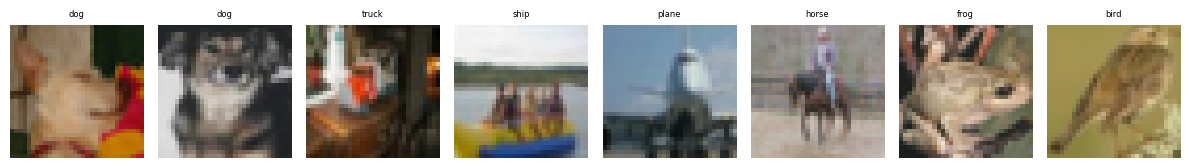

In [ ]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# without augmentation
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# with horizontal + vertical flip
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
full_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

n_total = len(full_base)        # 50000
n_train = int(0.8 * n_total)   # 40000
n_val   = n_total - n_train    # 10000

gen = torch.Generator().manual_seed(42)
train_base, val_base = random_split(full_base, [n_train, n_val], generator=gen)
train_aug,  val_aug  = random_split(full_aug,  [n_train, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(train_set, val_set):
    tr = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tr, vl, te

loaders = {
    'no_aug': make_loaders(train_base, val_base),
    'aug':    make_loaders(train_aug,  val_aug)
}

print(f'train={n_train}  val={n_val}  test={len(test_data)}')

imgs, labels = next(iter(loaders['no_aug'][0]))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * np.array(std) + np.array(mean)
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Patch Embedding

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # use conv to split image into patches and project
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)           # (B, embed_dim, H/p, W/p)
        x = x.flatten(2)           # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x

### Vision Transformer

In [ ]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super(ViT, self).__init__()

        self.patch_embed  = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches       = (img_size // patch_size) ** 2

        # learnable CLS token
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding
        self.pos_embed    = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x)
        # take CLS token output for classification
        out = self.head(x[:, 0])
        return out

### ResNet-18 Baseline

In [ ]:
def get_resnet18():
    model = models.resnet18(weights=None)
    # adjust first conv for 32x32 input
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model

### Loss Functions - CE, Label Smoothing, Focal

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_criterion(loss_type):
    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smooth':
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif loss_type == 'focal':
        return FocalLoss(gamma=2.0)

### Optimizer Factory

In [ ]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

### Train and Eval Loops

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            loss  = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

### Main Experiment Runner

In [ ]:
results       = {}
saved_models  = {}

def run_experiment(arch, loss_type, opt_name, aug_mode):
    name = f'{arch}_{loss_type}_{opt_name}_{aug_mode}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type,
        'optimizer': opt_name, 'augmentation': aug_mode, 'epochs': EPOCHS
    })

    train_loader, val_loader, test_loader = loaders[aug_mode]

    if arch == 'vit':
        model = ViT(
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
            embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
        ).to(DEVICE)
    else:
        model = get_resnet18().to(DEVICE)

    criterion = get_criterion(loss_type)
    optimizer = get_optimizer(model, opt_name)

    best_val_acc = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss':   vl_loss, 'val_acc':   vl_acc
        })
        print(f'  epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # load best checkpoint and test
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    print(f'  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')
    wandb.log({'test_loss': te_loss, 'test_acc': te_acc})

    results[name]      = {'test_acc': te_acc, 'test_loss': te_loss}
    saved_models[name] = model

    wandb.finish()
    return model

### Quick Test - run this first

In [ ]:
run_experiment('vit',      'ce', 'adam', 'no_aug')
run_experiment('resnet18', 'ce', 'adam', 'no_aug')


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7947  train_acc=0.3187  val_loss=1.5524  val_acc=0.4219
  epoch 2/4  train_loss=1.4519  train_acc=0.4638  val_loss=1.3102  val_acc=0.5182
  epoch 3/4  train_loss=1.2373  train_acc=0.5455  val_loss=1.1884  val_acc=0.5700
  epoch 4/4  train_loss=1.1287  train_acc=0.5915  val_loss=1.0575  val_acc=0.6170
  test_loss=1.0674  test_acc=0.6134


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▄▆█
val_loss,█▅▃▁
epoch,4
test_acc,0.6134
test_loss,1.0674
train_acc,0.59147



starting: resnet18_ce_adam_no_aug


  epoch 1/4  train_loss=1.2611  train_acc=0.5393  val_loss=1.0550  val_acc=0.6294
  epoch 2/4  train_loss=0.7878  train_acc=0.7214  val_loss=0.7701  val_acc=0.7274
  epoch 3/4  train_loss=0.5896  train_acc=0.7930  val_loss=0.7185  val_acc=0.7545
  epoch 4/4  train_loss=0.4468  train_acc=0.8427  val_loss=0.6567  val_acc=0.7827
  test_loss=0.6728  test_acc=0.7845


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▅▇█
val_loss,█▃▂▁
epoch,4
test_acc,0.7845
test_loss,0.67278
train_acc,0.84272


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Full Grid - all combinations

In [ ]:
for arch in MODELS:
    for aug in AUG_MODES:
        for lf in LOSS_FNS:
            for opt in OPTIMIZERS:
                run_experiment(arch, lf, opt, aug)


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7980  train_acc=0.3220  val_loss=1.5693  val_acc=0.4136
  epoch 2/4  train_loss=1.4290  train_acc=0.4737  val_loss=1.2891  val_acc=0.5342
  epoch 3/4  train_loss=1.2395  train_acc=0.5477  val_loss=1.1583  val_acc=0.5767
  epoch 4/4  train_loss=1.1202  train_acc=0.5941  val_loss=1.0301  val_acc=0.6317
  test_loss=1.0455  test_acc=0.6189


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▅▆█
val_loss,█▄▃▁
epoch,4
test_acc,0.6189
test_loss,1.04551
train_acc,0.59413



starting: vit_ce_sgd_no_aug


  epoch 1/4  train_loss=1.8945  train_acc=0.2919  val_loss=1.7252  val_acc=0.3589
  epoch 2/4  train_loss=1.6700  train_acc=0.3783  val_loss=1.5852  val_acc=0.4164
  epoch 3/4  train_loss=1.5597  train_acc=0.4282  val_loss=1.5008  val_acc=0.4557
  epoch 4/4  train_loss=1.4570  train_acc=0.4709  val_loss=1.4096  val_acc=0.4814
  test_loss=1.4178  test_acc=0.4803


...

  epoch 1/4  train_loss=1.1546  train_acc=0.3828  val_loss=1.0797  val_acc=0.4200
  epoch 2/4  train_loss=0.7998  train_acc=0.5335  val_loss=0.8426  val_acc=0.5306
  epoch 3/4  train_loss=0.6319  train_acc=0.6157  val_loss=0.7639  val_acc=0.5680
  epoch 4/4  train_loss=0.5455  train_acc=0.6587  val_loss=0.5981  val_acc=0.6414
  test_loss=0.6232  test_acc=0.6309


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▄▆█
val_loss,█▅▃▁
epoch,4
test_acc,0.6309
test_loss,0.62317
train_acc,0.6587



starting: resnet18_focal_rmsprop_aug


  epoch 1/4  train_loss=1.2408  train_acc=0.3550  val_loss=1.0366  val_acc=0.4292
  epoch 2/4  train_loss=0.8084  train_acc=0.5300  val_loss=1.1069  val_acc=0.4748
  epoch 3/4  train_loss=0.6319  train_acc=0.6146  val_loss=0.8063  val_acc=0.5472
  epoch 4/4  train_loss=0.5305  train_acc=0.6650  val_loss=0.7701  val_acc=0.5801
  test_loss=0.8179  test_acc=0.5662


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▃▆█
val_loss,▇█▂▁
epoch,4
test_acc,0.5662
test_loss,0.81791
train_acc,0.66497


### Results Summary

In [ ]:
print(f'{"config":<50} {"test_acc":>10} {"test_loss":>10}')
print('-' * 72)
for k, v in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'{k:<50} {v["test_acc"]:>10.4f} {v["test_loss"]:>10.4f}')

best = max(results, key=lambda x: results[x]['test_acc'])
print(f'\nbest: {best}  acc={results[best]["test_acc"]:.4f}')

config                                               test_acc  test_loss
------------------------------------------------------------------------
resnet18_label_smooth_adam_no_aug                      0.7678     1.0531
resnet18_ce_adam_no_aug                                0.7522     0.7736
resnet18_focal_adam_no_aug                             0.7333     0.4343
resnet18_label_smooth_adam_aug                         0.7261     1.1239
resnet18_ce_rmsprop_no_aug                             0.7053     0.8484
resnet18_label_smooth_rmsprop_no_aug                   0.7008     1.1889
resnet18_focal_rmsprop_no_aug                          0.6987     0.5035
resnet18_ce_sgd_no_aug                                 0.6937     0.9590
resnet18_ce_adam_aug                                   0.6927     0.8776
resnet18_label_smooth_sgd_no_aug                       0.6921     1.2280
resnet18_focal_sgd_no_aug                              0.6790     0.5882
resnet18_ce_sgd_aug                                

### Upload to HuggingFace

In [ ]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_models.keys():
    fname = f'{name}_best.pt'
    if os.path.exists(fname):
        api.upload_file(
            path_or_fileobj=fname,
            path_in_repo=f'models/{fname}',
            repo_id=HF_REPO
        )
        print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vit_ce_adam_no_aug_best.pt  :  17%|#6        |  564kB / 3.40MB            

uploaded: vit_ce_adam_no_aug_best.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

uploaded: resnet18_focal_sgd_aug_best.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...focal_rmsprop_aug_best.pt:   9%|8         | 3.91MB / 44.8MB            

uploaded: resnet18_focal_rmsprop_aug_best.pt
https://huggingface.co/mraidtu/exp10-vit-resnet


In [ ]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/manishrai_25afi23-delhi-technological-university/exp10-vit-resnet
HF  : https://huggingface.co/mraidtu/exp10-vit-resnet
